In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

import time
!pip install python-docx
from docx import Document
from docx.shared import Inches

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 3.9 MB/s eta 0:00:00


In [ ]:
#Reading df_basic
df_name = 'df_basic_1.0' # normalized/255, resized (64,64) and grey

drive.mount('/content/drive')
df_basic = pd.read_pickle("/content/drive/My Drive/Team Project X-Rays/Dataframes/df_basic_1.0.pkl")
# Setting the image name as Index and display the first 5 lines
df_basic = df_basic.set_index('Name')
df_basic.head()

Mounted at /content/drive


,Case,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
Name,,,,,,,,,,,,,,,,,,,,,
COVID-122,COVID,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.976471,...,0.968627,0.956863,0.945098,0.925490,0.905882,0.894118,0.882353,0.854902,0.839216,0.788235
COVID-1689,COVID,0.203922,0.050980,0.043137,0.039216,0.039216,0.043137,0.070588,0.054902,0.074510,...,0.807843,0.803922,0.733333,0.654902,0.600000,0.513725,0.427451,0.164706,0.172549,0.172549
COVID-2636,COVID,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.756863,0.745098,0.737255,0.752941,0.737255,0.713725,0.690196,0.686275,0.647059,0.631373
COVID-3007,COVID,0.074510,0.050980,0.027451,0.031373,0.031373,0.019608,0.003922,0.133333,0.380392,...,0.768627,0.764706,0.752941,0.752941,0.650980,0.619608,0.156863,0.000000,0.000000,0.000000
COVID-1620,COVID,0.152941,0.133333,0.133333,0.133333,0.133333,0.137255,0.129412,0.133333,0.133333,...,0.517647,0.498039,0.498039,0.470588,0.423529,0.364706,0.423529,0.486275,0.415686,0.317647


In [ ]:
# Encode classes as numbers (LabelEncoder)
le = LabelEncoder()
df_basic['Case'] = le.fit_transform(df_basic['Case'])

# Splitting data into features (X) and target (y)
X = df_basic.drop('Case', axis=1)
y = df_basic['Case']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


**PCA (Principal component analysis)**

In [ ]:
### --- PCA (Principal component analysis) --- ###

# Instantiating a PCA object (It shall generate as many components that are needed in order to explain 90 % of the datas variability)
pca = PCA(n_components = 0.9)

# Fit and transform the data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


The number of components needed to explain 90 % of the datas variability are: 57
The first two components explain 39.0 % of the variability.


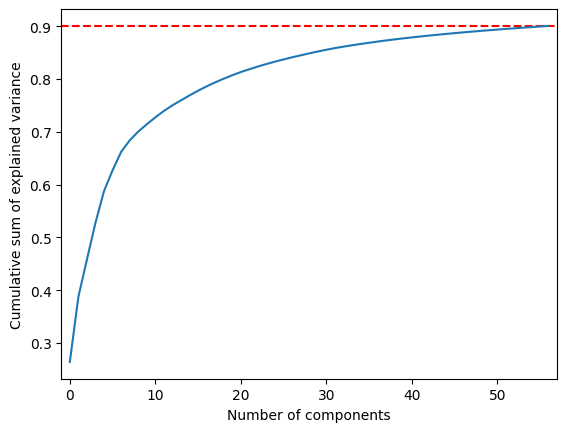

In [ ]:
# Report of how many dimensions are necessary to keep the majority of the informational content
print(f'The number of components needed to explain 90 % of the datas variability are: {pca.n_components_}')
print(f"The first two components explain {round(pca.explained_variance_ratio_[0:2].sum(),2)*100} % of the variability.")

# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 57)
plt.xlabel('Number of components')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

# Save image as .png
plt.savefig(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png', bbox_inches = 'tight')


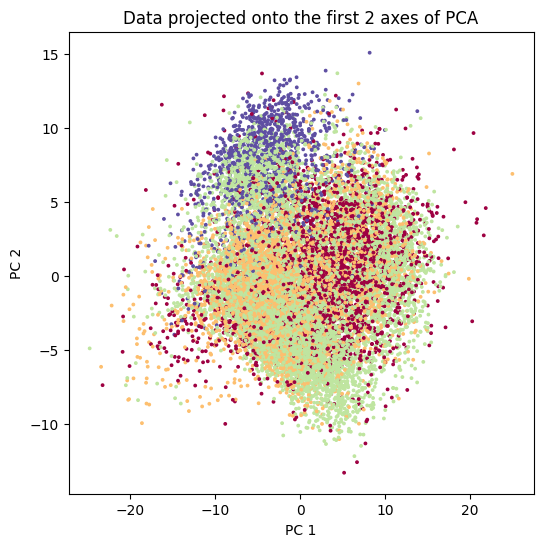

In [ ]:
# Plot the observations using the first two components of the PCA
plt.figure(figsize = (6,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c = y_train, s = 3, cmap=plt.cm.Spectral);
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.title("Data projected onto the first 2 axes of PCA")

# Save image as .png
plt.savefig(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png', bbox_inches = 'tight')



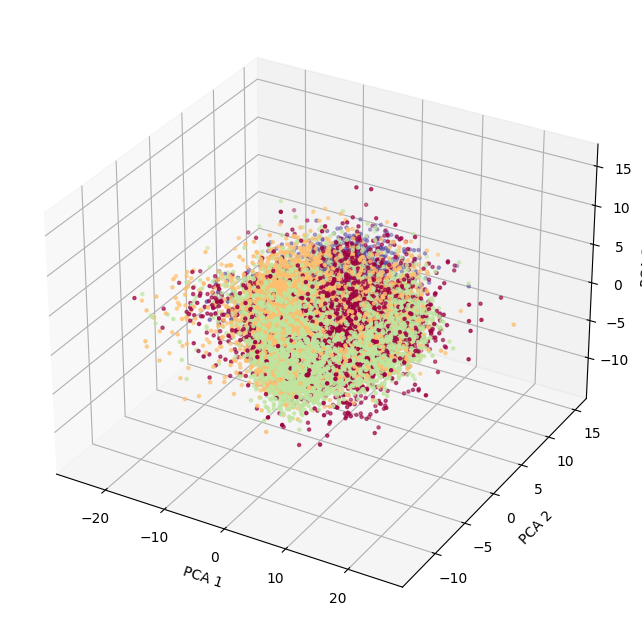

In [ ]:
# 3D plot of the first 3 principle components
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_pca[:,0], X_train_pca[:,1], X_train_pca[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

# Save image as .png
plt.savefig(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png', bbox_inches = 'tight')


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,0.002227,0.003163,0.003112,0.002715,0.002606,0.002404,0.002240,0.002064,0.001911,0.001975,...,0.021741,0.023122,0.024370,0.025097,0.025164,0.024524,0.023136,0.020931,0.018639,0.016155
PC2,0.005659,0.011761,0.014914,0.016735,0.018091,0.019859,0.021356,0.022497,0.023320,0.023987,...,-0.008033,-0.008865,-0.010196,-0.011798,-0.014036,-0.015896,-0.016490,-0.015443,-0.013742,-0.014687
PC3,0.002468,0.004794,0.005325,0.005650,0.005966,0.005913,0.005880,0.006046,0.005765,0.005746,...,-0.023996,-0.025808,-0.026955,-0.027225,-0.026085,-0.023815,-0.020430,-0.016400,-0.012119,-0.009227
PC4,-0.018895,-0.010332,-0.008813,-0.009089,-0.009409,-0.009257,-0.009077,-0.009240,-0.009384,-0.009402,...,0.003426,0.006537,0.010038,0.013727,0.017040,0.019917,0.022217,0.023568,0.022616,0.015822
PC5,0.005184,0.009786,0.010551,0.010708,0.010927,0.011049,0.011295,0.011370,0.011675,0.012063,...,0.012492,0.019189,0.026000,0.032303,0.037077,0.040072,0.040566,0.039483,0.036680,0.029894


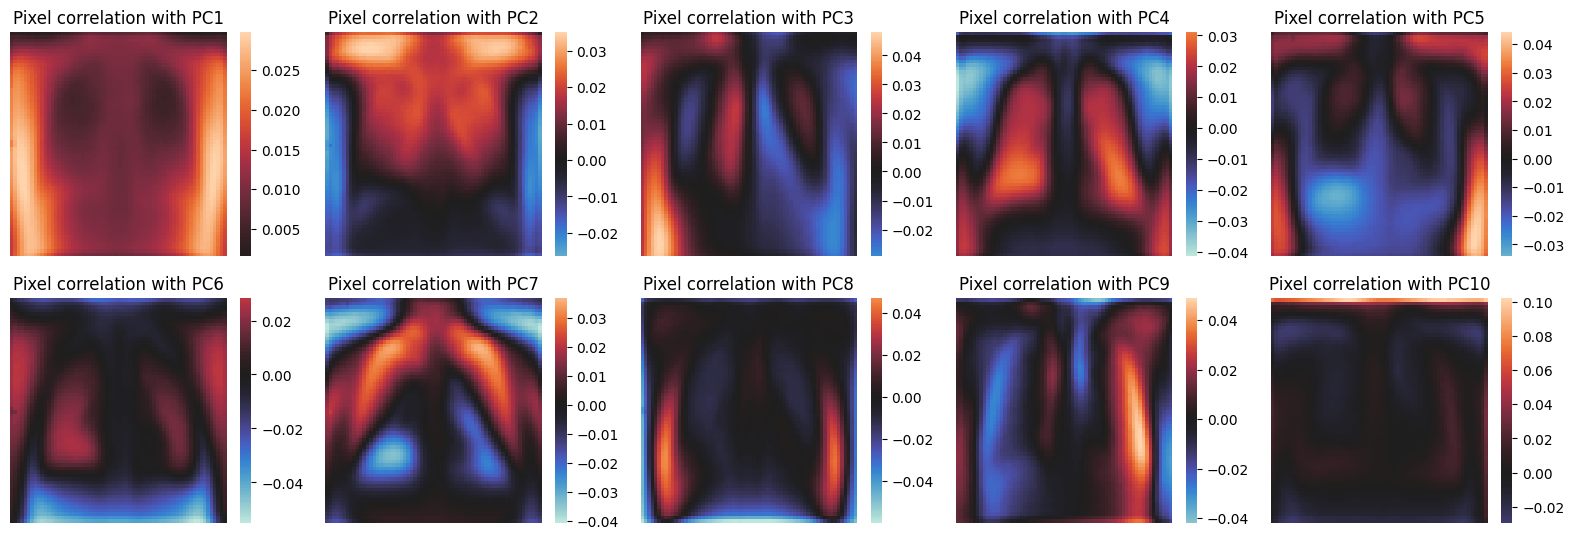

In [ ]:
### --- Interpretation of PCA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 57 PCs and create a dataframe with this information (rows = PCs, columns = PXs)
corr_df = pd.DataFrame(pca.components_[0:pca.components_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(pca.components_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_PCA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_PCA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(2, 5, figsize=(16, 5.5))

for i in np.arange(0,10):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i // 5, i % 5]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with PC{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


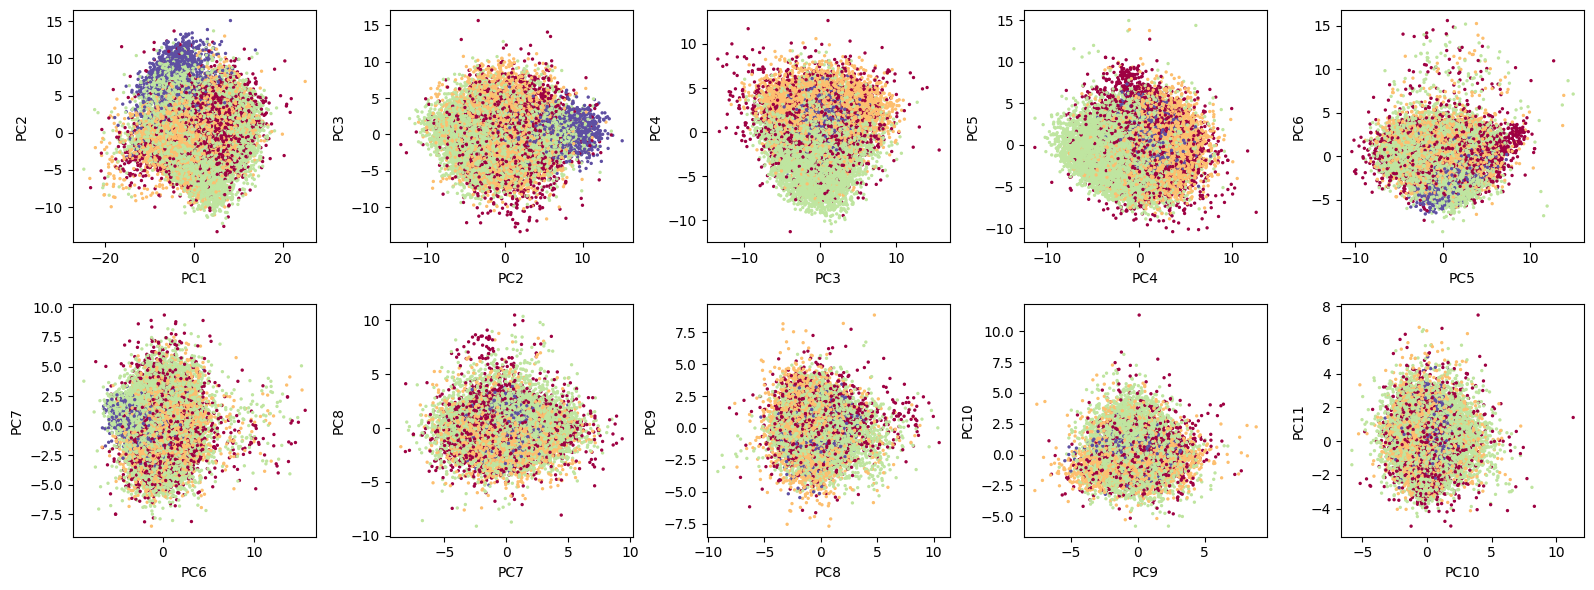

In [ ]:
# Plot the observations projected onto the different PC axes in decreasing order/importance
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in np.arange(0,10):
    ax = axes[i // 5, i % 5]
    ax.scatter(X_train_pca[:, i], X_train_pca[:, i+1], c=y_train, s=2, cmap=plt.cm.Spectral);
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{i+2}')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png', bbox_inches = 'tight')


**LDA (Linear discriminant analysis)**

In [ ]:
### --- LDA (Linear discriminant analysis) --- ###

lda = LDA()
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


In [ ]:
# Print the shape
X_train_lda.shape


(16884, 3)

Train score: 0.863302534944326
Test score: 0.6792229329542763


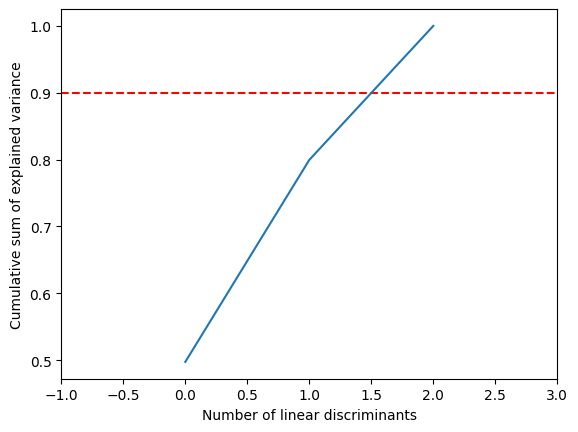

In [ ]:
# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 3)
plt.xlabel('Number of linear discriminants')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(lda.explained_variance_ratio_.cumsum())

# Save image as .png
plt.savefig(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png', bbox_inches = 'tight')

# Assess the score of 'LDA classification'
print(f'Train score: {lda.score(X_train, y_train)}')
print(f'Test score: {lda.score(X_test, y_test)}')

The first two components explain 80.0 % of the variability.


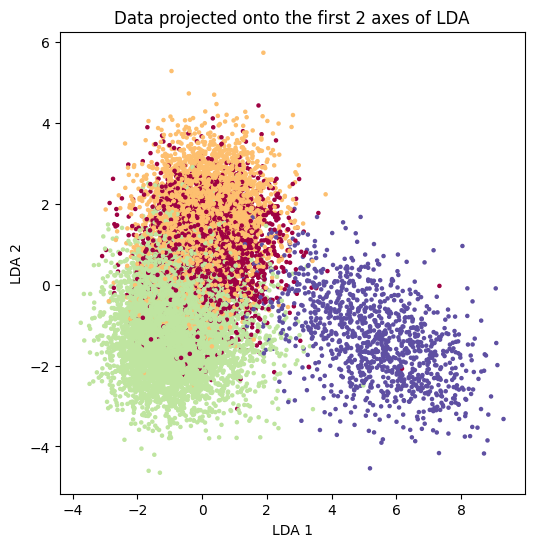

In [ ]:
# Report the explained variance for the first two components
print(f"The first two components explain {round(lda.explained_variance_ratio_[0:2].sum(),3)*100} % of the variability.")

# Plot the observations using the first two components of the LDA
plt.figure(figsize = (6,6))
plt.scatter(X_train_lda[:,0], X_train_lda [:,1], c = y_train, s = 5, cmap=plt.cm.Spectral);
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')

plt.title("Data projected onto the first 2 axes of LDA")

# Save image as .png
plt.savefig(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png', bbox_inches = 'tight')


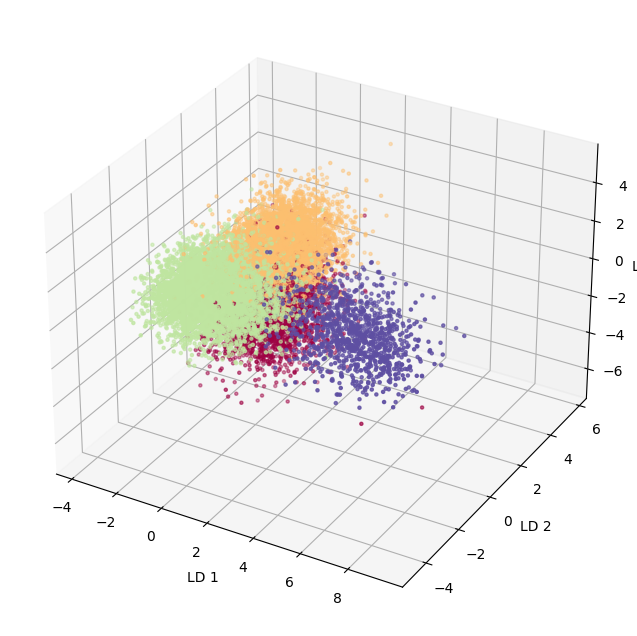

In [ ]:
# 3D plot of all 3 linear discriminants
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_lda[:,0], X_train_lda[:,1], X_train_lda[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('LD 1')
ax.set_ylabel('LD 2')
ax.set_zlabel('LD 3')

# Save image as .png
plt.savefig(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png', bbox_inches = 'tight')



,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
PC1,-0.471745,0.693507,-0.717276,-0.761406,-1.590550,3.876189,-5.087796,1.335340,1.285917,-0.574867,...,-1.083795,0.792644,0.601841,-1.200464,0.306315,-0.498818,0.694115,1.560743,-5.229127,6.258880
PC2,0.215250,1.890221,-0.411765,-0.578083,0.078461,0.906314,-0.067515,-0.481075,-0.465950,0.807846,...,0.733401,-0.745383,0.490339,-0.565341,0.379492,0.258472,-0.562329,0.546020,0.022394,-0.229091
PC3,-0.337786,-0.178235,-0.756312,0.560740,0.955854,-0.363316,0.998131,-0.899027,0.081509,-0.609723,...,0.395471,-0.258706,-0.145603,-0.092150,-0.216179,-0.164661,0.914306,-0.988538,2.075758,-1.601282
PC4,2.854755,-8.819511,9.425044,0.338162,-3.328956,-11.551708,6.290510,5.350902,-1.981830,2.571829,...,-3.331263,3.126095,-2.659722,6.374742,-0.853804,1.430336,-6.267452,0.905769,-1.859616,-3.547236


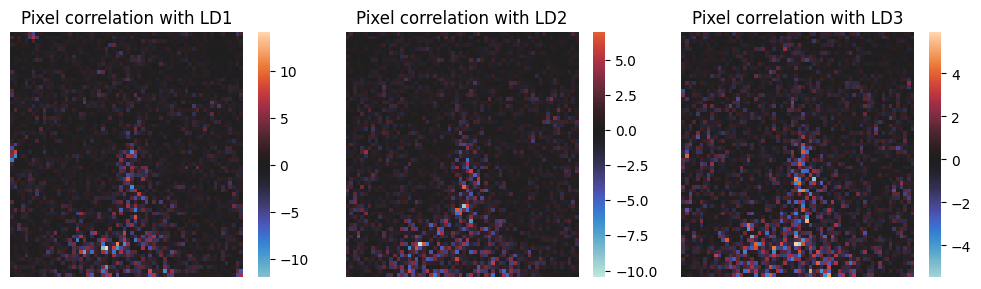

In [ ]:
### --- Interpretation of LDA (which parts of the images are important) --- ###

# Get the correlations of each pixel to the 3 PCs and create a dataframe with this information (rows = LDs, columns = PXs)
corr_df = pd.DataFrame(lda.coef_[0:lda.coef_.shape[0]+1,:], columns= X.columns, index = [f'PC{i+1}' for i in range(lda.coef_.shape[0])])
display(corr_df.head())

# Convert rows of corr_df to a image-shaped numpy array (64,64)
def row_to_image_array (df, number_LDA):
  # Convert row to a numpy array
  row_as_array = corr_df.iloc[number_LDA].values
  # Reshape the numpy array to our current image size (64x64)
  reshaped_array = np.reshape(row_as_array, (64, 64))
  return reshaped_array

# Plotting the correlation of each pixel with the first 10 PCs as an image shaped heat-map in a 2x5 raster
# Define colormap
sns.color_palette("icefire", as_cmap=True)
# Create the subplot grid
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in np.arange(0,3):
    # Generate the reshaped array for row i
    reshaped_array = row_to_image_array(corr_df, i)
    # Define position in the subplot grid
    ax = axes[i]
    # Plot the heatmap
    sns.heatmap(reshaped_array, ax=ax,  center=0, cmap='icefire')
    ax.set_title(f'Pixel correlation with LD{i+1}')
    ax.axis('off')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png', bbox_inches = 'tight')


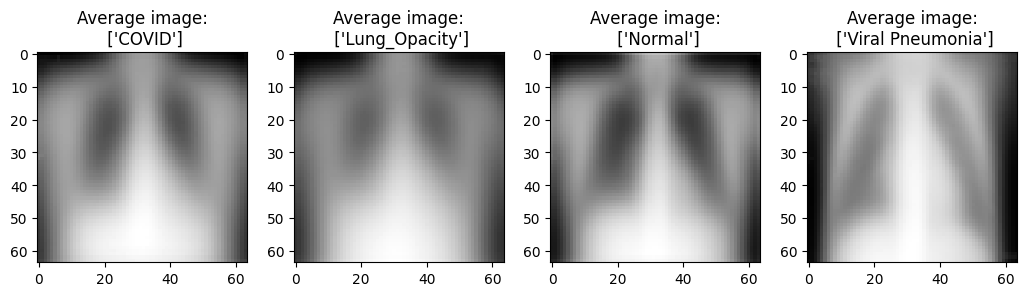

In [ ]:
# Generating and displaying the average image of each class
X_array = X.to_numpy()
y_array = y.to_numpy()

plt.figure(figsize = (16,6))
for i in np.arange(0,4):
    indices = np.where(y==i)[0]
    average_image = X_array[indices].mean(axis=0)
    reshaped_average_image = np.reshape(average_image, (64, 64))
    plt.subplot(2,5, i+1)
    plt.imshow(reshaped_average_image, cmap='gray')
    plt.title(f'Average image:\n {le.inverse_transform([i])}')

# Save image as .png
plt.savefig(f'/content/Average image of each class_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Generate random data for test purposes
np.random.seed(0)  # For reproducibility
data = np.random.randn(100, 9)  # 9 feature columns

# Create target column with integers 1-4
target = np.random.randint(1, 5, size=(100, 1))

# Concatenate target and feature columns
data = np.hstack((target, data))

# Create a DataFrame
df = pd.DataFrame(data, columns=['target'] + [f'feature_{i}' for i in range(9)])
display(df.head())

# Encode classes as numbers (LabelEncoder)
lenc = LabelEncoder()
df['target'] = lenc.fit_transform(df['target'])

data = df.drop('target', axis=1)
target = df['target']

# Splitting data into training and testing sets
X_train__check, X_test__check, y_train_check, y_test_check = train_test_split(data, target, test_size=0.2)


,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
0,3.0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219
1,4.0,0.410599,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158
2,2.0,0.313068,-0.854096,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759
3,2.0,-0.187184,1.532779,1.469359,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349
4,3.0,1.230291,1.202380,-0.387327,-0.302303,-1.048553,-1.420018,-1.706270,1.950775,-0.509652


In [ ]:
### --- Test predictive performance with different techniques of dimension reduction applied to the data set --- ###

# Setting up four different models
lr = LogisticRegression(solver='lbfgs', C = 1.0, max_iter=10000)
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
svc = SVC(gamma = 0.01, kernel = "poly")
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=123)

# Define function to test model performance
def test_performance(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    cl_report = classification_report(y_te, model.predict(X_te), output_dict=True)
    cl_report_df = pd.DataFrame(cl_report).transpose()
    f1_scores_covid = cl_report_df.iloc[le.transform(['COVID'])[0]]['f1-score']
    f1_score_opacity = cl_report_df.iloc[le.transform(['Lung_Opacity'])[0]]['f1-score']
    f1_score_normal = cl_report_df.iloc[le.transform(['Normal'])[0]]['f1-score']
    f1_score_pneumonia = cl_report_df.iloc[le.transform(['Viral Pneumonia'])[0]]['f1-score']
    return model.score(X_train, y_train), model.score(X_test, y_test), f1_scores_covid, f1_score_opacity, f1_score_normal, f1_score_pneumonia


# Create list of data sets to be analysed
datasets = [
    (X_train, X_test, y_train, y_test, 'No dimension reduction'),
    (X_train_pca, X_test_pca, y_train, y_test, 'PCA'),
    (X_train_lda, X_test_lda, y_train, y_test, 'LDA'),
    #(X_train__check, X_test__check, y_train_check, y_test_check, 'check')
    ]

# Create list of models to be tested
models = [
    (lr, 'LogisticRegression'),
     (knn, 'KNeighbors'),
      (svc, 'SVC'),
       (dt, 'DecisionTree')
       ]

# Create empty lists to store results
model_names =[]
dataset_names = []
model_scores = []
execution_times = []

# Loop through the different models and data sets to determine the
# performance of each model on each test set
for model, model_name in models:
  for X_tr, X_te, y_tr, y_te, dataset_name in datasets:
    # Add model name to list
    model_names.append(model_name)
    # Add dataset name to the list
    dataset_names.append(dataset_name)
    # Record the start time
    start_time = time.time()
    # Fit model and calculate train and test score
    model_scores.append(test_performance(X_tr, X_te, y_tr, y_te,model))
    # Record the end time
    end_time = time.time()
    # Calculate the execution time
    execution_time = (end_time - start_time)/60
    # Add execution time to the list
    execution_times.append(execution_time)

# Create a DataFrame with the results and display it
results = pd.DataFrame({'Model': model_names, 'Dataset': dataset_names, 'Train_accuracy': np.array(model_scores)[:,0], 'Test_accuracy': np.array(model_scores)[:,1], 'f1_covid' : np.array(model_scores)[:,2],
                        'f1_lung_opacity' : np.array(model_scores)[:,3], 'f1_normal' : np.array(model_scores)[:,4], 'f1_pneumonia' : np.array(model_scores)[:,5], 'f1_mean' : np.array(model_scores)[:,2:6].mean(axis=1), 'Execution time [min]': execution_times})
display(results)


,Model,Dataset,Train_accuracy,Test_accuracy,f1_covid,f1_lung_opacity,f1_normal,f1_pneumonia,f1_mean,Execution time [min]
0,LogisticRegression,No dimension reduction,0.867685,0.716655,0.543660,0.666941,0.786349,0.825279,0.705557,28.852391
1,LogisticRegression,PCA,0.717662,0.709074,0.424889,0.683657,0.788915,0.780583,0.669511,0.031057
2,LogisticRegression,LDA,0.865672,0.678512,0.504029,0.630884,0.758855,0.720450,0.653555,0.002317
3,KNeighbors,No dimension reduction,0.826048,0.781805,0.654107,0.732303,0.839739,0.880769,0.776729,2.522174
4,KNeighbors,PCA,0.831260,0.780147,0.646875,0.726376,0.841907,0.861224,0.769096,0.071351
5,KNeighbors,LDA,0.877932,0.665956,0.494382,0.611977,0.752036,0.717268,0.643916,0.022306
6,SVC,No dimension reduction,1.000000,0.794125,0.683168,0.762095,0.839851,0.898438,0.795888,24.342631
7,SVC,PCA,0.888237,0.798863,0.662894,0.758109,0.855355,0.875764,0.788030,0.625351
8,SVC,LDA,0.614487,0.561005,0.238153,0.244816,0.685804,0.622871,0.447911,0.279779
9,DecisionTree,No dimension reduction,0.652748,0.624733,0.419561,0.573034,0.736455,0.543478,0.568132,0.350783


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx', index=False)

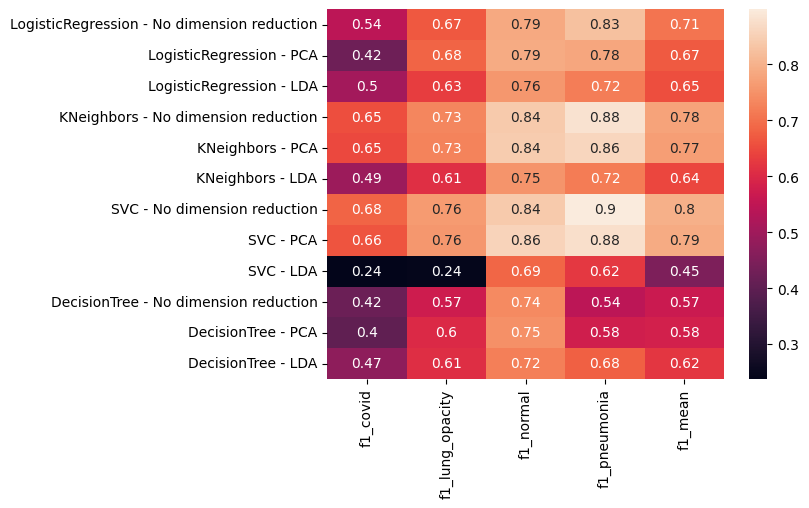

In [ ]:
# Create a heatmap for visual interpretation
orange_pallet = sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(results[['f1_covid', 'f1_lung_opacity', 'f1_normal', 'f1_pneumonia', 'f1_mean']], yticklabels= results['Model']+' - '+results['Dataset'], annot = True)#, cmap = 'dark:salmon_r')

# Save image as .png
plt.savefig(f'/content/Heatmap_model_performance_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Insert grafics in word-docx
# Create a word document
doc = Document()

# Create a heading
doc.add_heading(f'The impact of dimension reduction - Images for the analysis of {df_name}', 0)

# Add graphs to the document
doc.add_picture(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
doc.add_picture(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
doc.add_picture(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
doc.add_picture(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
doc.add_picture(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
doc.add_picture(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
doc.add_picture(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
doc.add_picture(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/Average image of each class_{df_name}.png')
doc.add_picture(f'/content/Heatmap_model_performance_{df_name}.png')

# Save word document
doc.save(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')



In [ ]:
# Downloads
files.download(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
files.download(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
files.download(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
files.download(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
files.download(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
files.download(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
files.download(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
files.download(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/Average image of each class_{df_name}.png')
files.download(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx')
files.download(f'/content/Heatmap_model_performance_{df_name}.png')
files.download(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>